In [1]:
import os
from pathlib import Path
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure
from model_ranking.utils import (
    load_h5,
    get_random_colors,
)


INFO: P [MainThread] 2025-11-06 09:53:30,107 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from numpy.typing import NDArray
from typing import Any

def enhance_image(im: NDArray[Any], do_norm:bool=True)->NDArray[Any]:
    # apply CLAHE to improve the image quality
    if do_norm:
        im -= im.min(axis=(0, 1), keepdims=True)
        im /= (im.max(axis=(0, 1), keepdims=True) + 1e-6)
    im = exposure.equalize_adapthist(im) #pyright: ignore
    im *= 255 #pyright: ignore
    return im #pyright: ignore

In [3]:
covid_gt_dir_path = Path("/g/kreshuk/talks/data/covid_if")
gt_paths = sorted(glob(os.path.join(covid_gt_dir_path, "*.h5")))

In [4]:
print(len(gt_paths))

49


# CellPose SAM Predictions

In [23]:
base_path = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Cellpose_SAM/percentiles2_0_99/consistency/cpsam/none")
metric_summary_path = base_path / "metric_summary_full.h5"
mSA_per_patch = load_h5(metric_summary_path, "mSA_scores")

In [24]:
np.median(mSA_per_patch, axis=0)

array([0.34265619, 0.76129032, 0.25341426])

In [25]:
ids_cpsam = np.where((mSA_per_patch[:, 0] > 0.34) & (mSA_per_patch[:, 0] < 0.35))[0]
print(len(ids_cpsam))

4


In [26]:
ids_cpsam

array([20, 29, 36, 38])

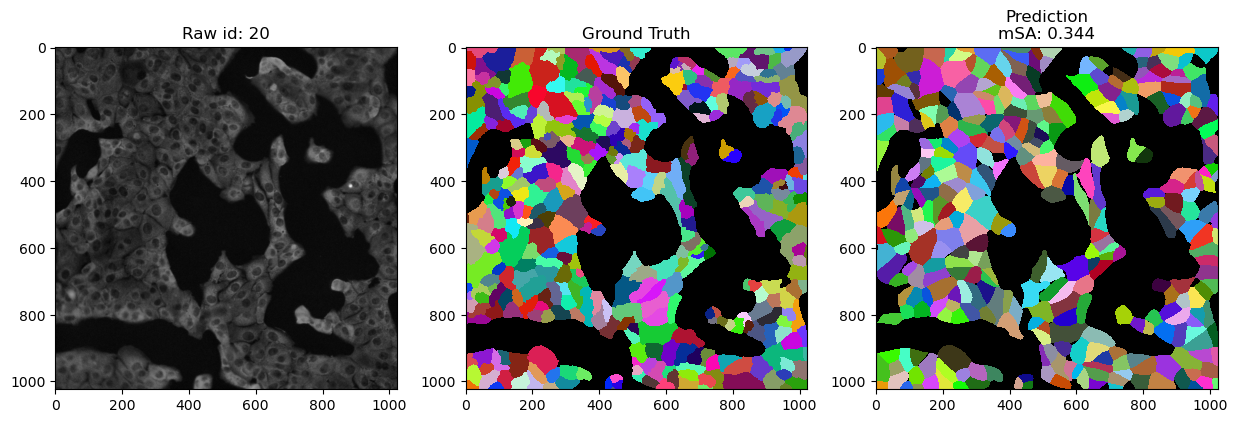

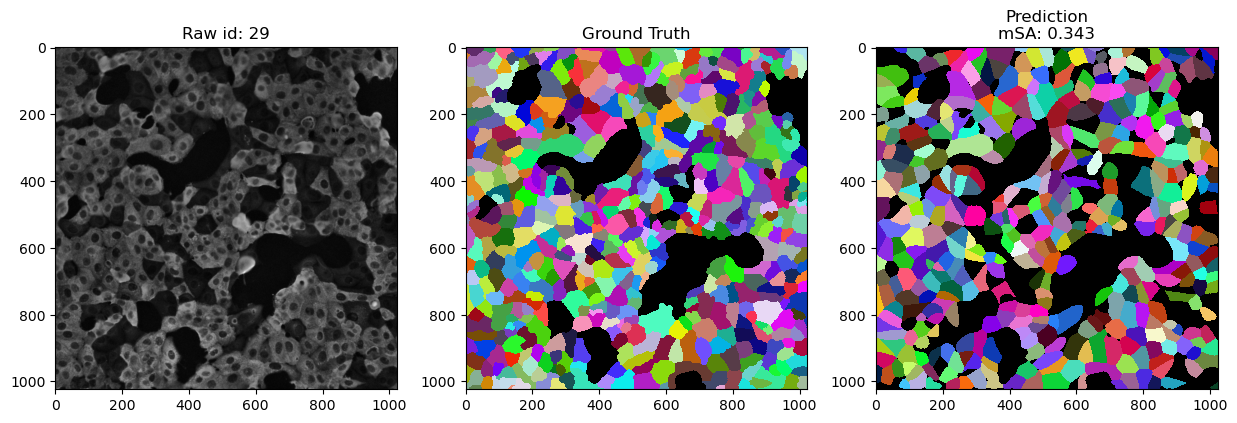

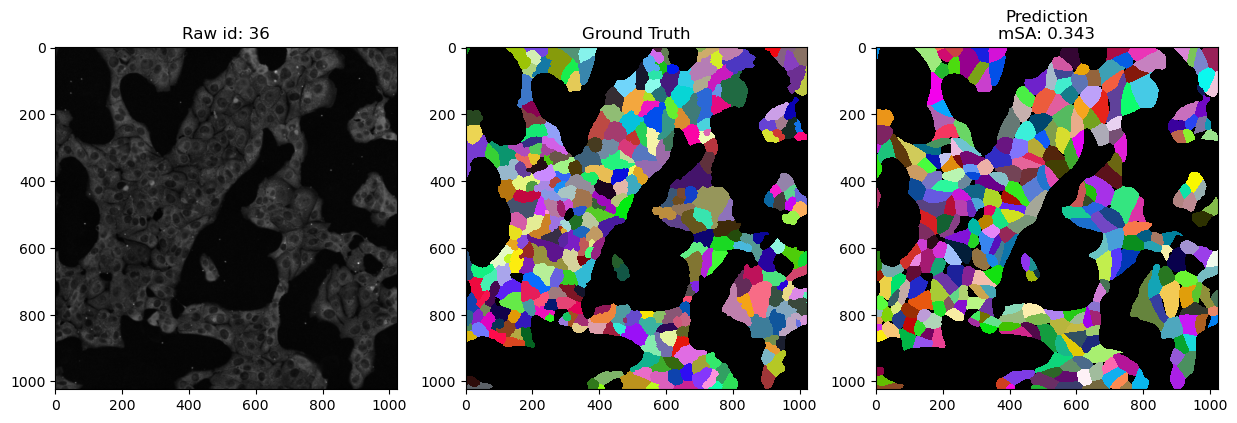

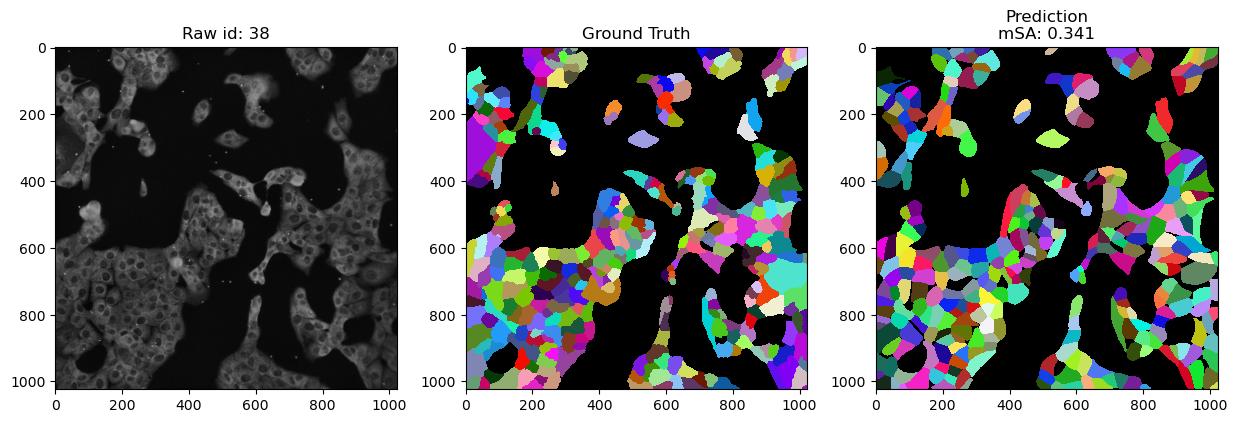

In [35]:
pred_path = base_path / "predictions"
for i in ids_cpsam:
    gt_name = f"gt_image_{i:03d}.h5"
    gt_path = covid_gt_dir_path / gt_name
    pred_path = base_path / "predictions" / f"sample_{i:03d}.h5"
    raw = load_h5(gt_path, "raw/serum_IgG/s0")
    gt = load_h5(gt_path, "labels/cells/s0")
    pred = load_h5(pred_path, "prediction")
    mSA_score = load_h5(pred_path, "mSA_scores")[0]

    raw_enhanced = enhance_image(raw)
    _, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(raw_enhanced.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw id: {i}")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].set_title("Ground Truth")
    axs[2].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
    axs[2].set_title(f"Prediction\nmSA: {mSA_score:.3f}")
    plt.show()


# MicroSAM (VIT-t) predictions

In [36]:
base_path_vit_t = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/Micro_SAM/percentiles_0_99/consistency/vit_t_lm/none")
ms_path_vit_t = base_path_vit_t / "metric_summary_full.h5"
mSA_per_patch_vit_t = load_h5(ms_path_vit_t, "mSA_scores")

In [37]:
print(np.median(mSA_per_patch_vit_t, axis=0))

[0.13015843 0.33557047 0.08228571]


In [38]:
ids_vit_t = np.where((mSA_per_patch_vit_t[:, 0] > 0.13) & (mSA_per_patch_vit_t[:, 0] < 0.14))[0]
print(len(ids_vit_t))

6


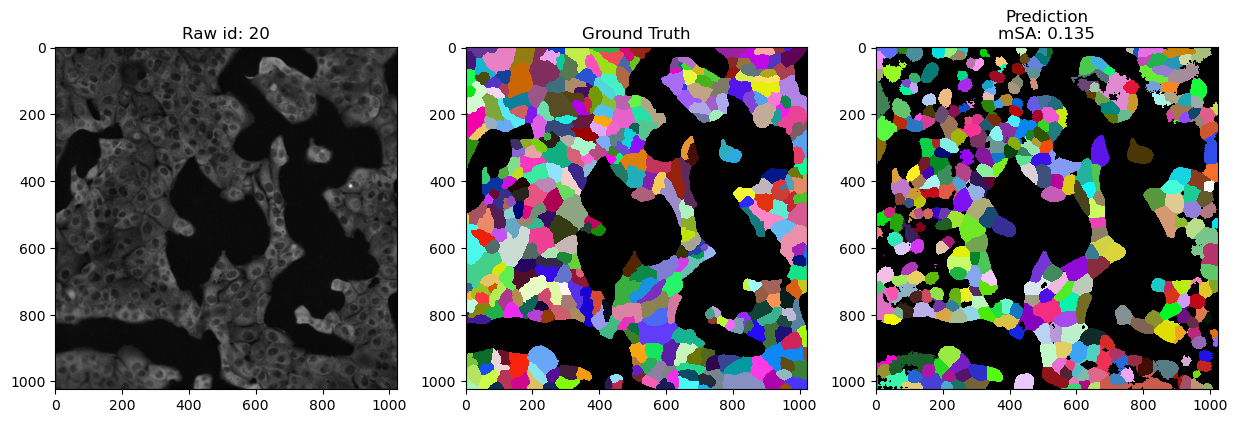

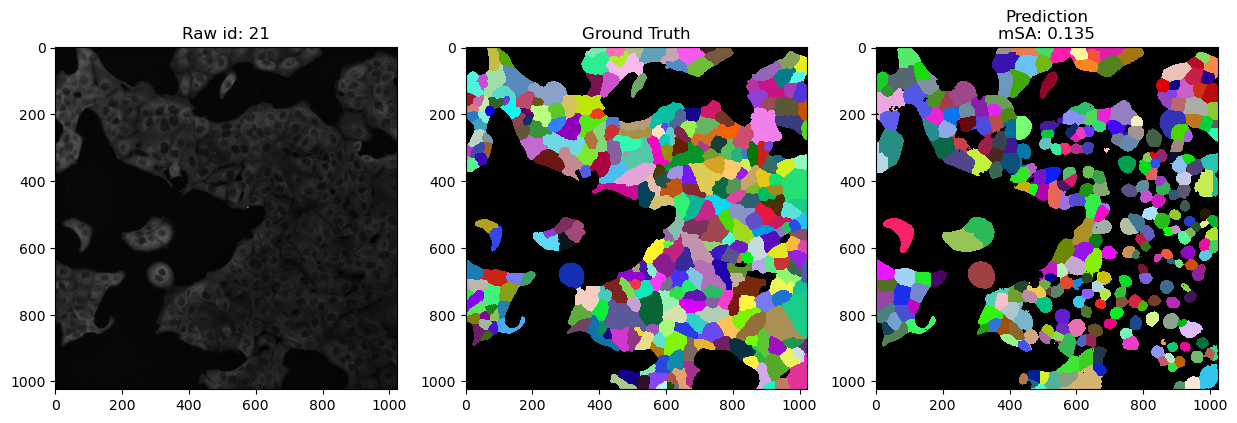

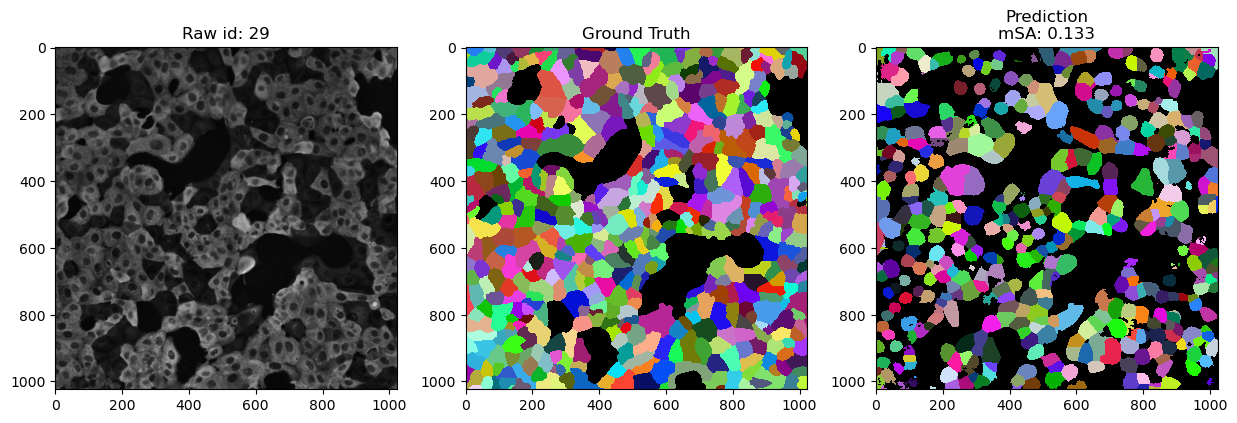

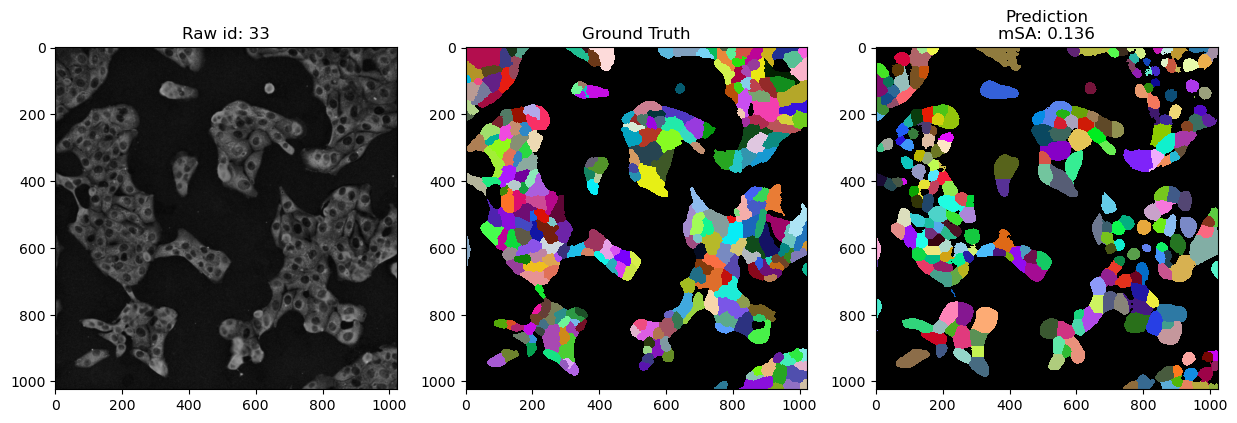

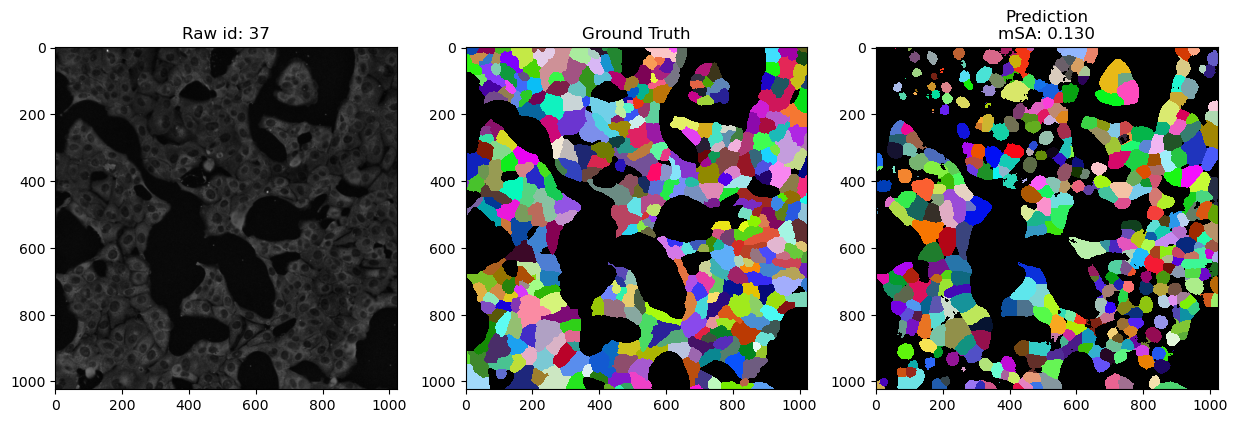

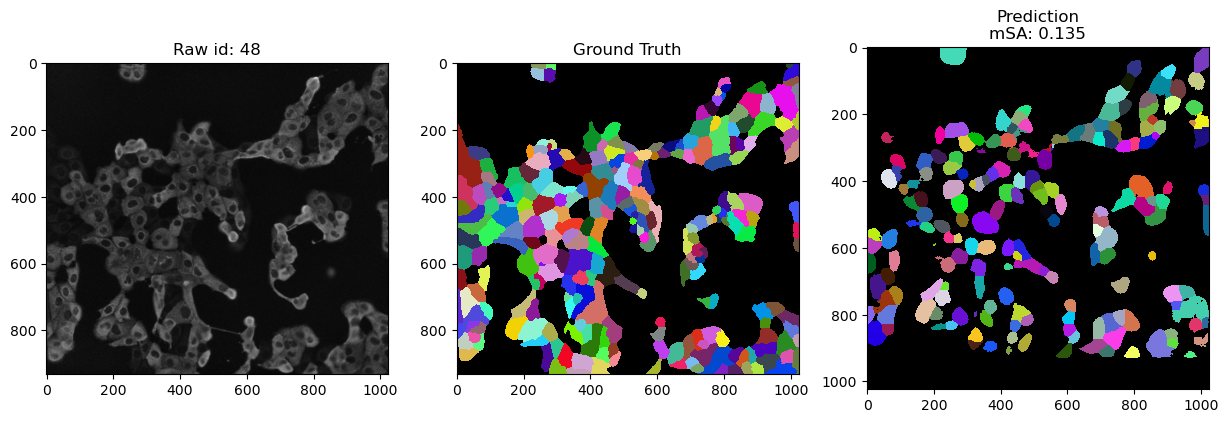

In [40]:
for i in ids_vit_t:
    gt_name = f"gt_image_{i:03d}.h5"
    gt_path = covid_gt_dir_path / gt_name
    pred_path = base_path_vit_t / "predictions" / f"sample_{i:03d}.h5"
    raw = load_h5(gt_path, "raw/serum_IgG/s0")
    gt = load_h5(gt_path, "labels/cells/s0")
    pred = load_h5(pred_path, "prediction")
    mSA_score = load_h5(pred_path, "mSA_scores")[0]

    raw_enhanced = enhance_image(raw)
    _, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(raw_enhanced.squeeze(), cmap="gray")
    axs[0].set_title(f"Raw id: {i}")
    axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
    axs[1].set_title("Ground Truth")
    axs[2].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
    axs[2].set_title(f"Prediction\nmSA: {mSA_score:.3f}")
    plt.show()


# Patch id=29

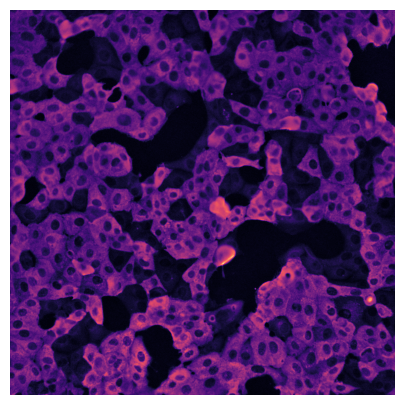

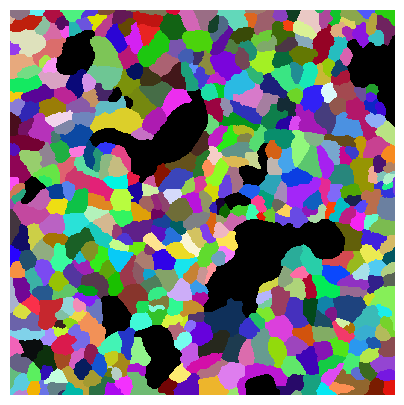

In [42]:
i = 29
gt_name = f"gt_image_{i:03d}.h5"
gt_path = covid_gt_dir_path / gt_name

raw = load_h5(gt_path, "raw/serum_IgG/s0")
gt = load_h5(gt_path, "labels/cells/s0")

raw_enhanced = enhance_image(raw)

_ = plt.figure(figsize=(5,5))
_ = plt.imshow(raw_enhanced.squeeze(), cmap="magma")
_ = plt.axis('off')
_ = plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/instance_imgs/Covid_IF_raw.png', bbox_inches='tight', pad_inches=0)
plt.show()
_ = plt.figure(figsize=(5,5))
_ = plt.imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
_ = plt.axis('off')
_ = plt.savefig('/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/instance_imgs/Covid_IF_gt.png', bbox_inches='tight', pad_inches=0)
plt.show()

### CPSAM prediction

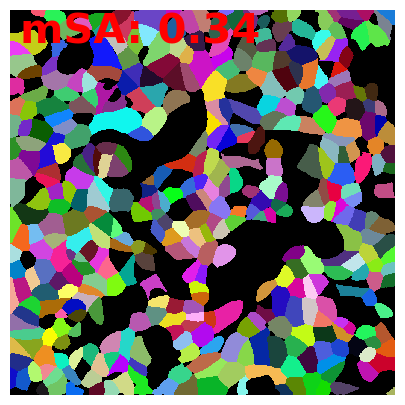

In [56]:
i = 29
font_size = 30
pred_path = base_path / "predictions" / f"sample_{i:03d}.h5"
pred = load_h5(pred_path, "prediction")
mSA_score = load_h5(pred_path, "mSA_scores")[0]

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation="nearest")
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.65, 0.89, f"mSA: {mSA_score:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/instance_imgs/cpsam_id29_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()

# Micro-SAM vit-t

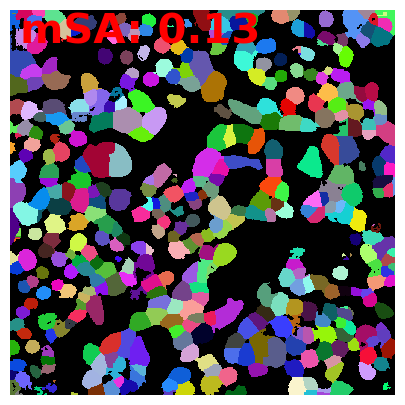

In [57]:
i = 29
font_size = 30
pred_path = base_path_vit_t / "predictions" / f"sample_{i:03d}.h5"
pred = load_h5(pred_path, "prediction")
mSA_score = load_h5(pred_path, "mSA_scores")[0]

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation="nearest")
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.65, 0.89, f"mSA: {mSA_score:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/instance_imgs/vit-t_id29_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()

## Powerful-Chipmunk

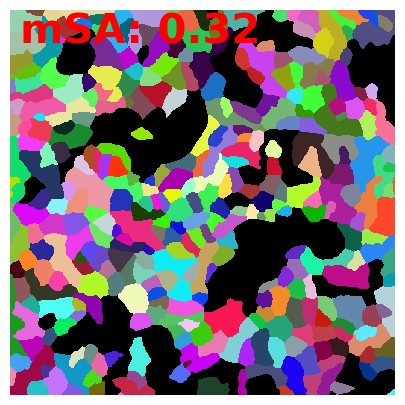

In [8]:
i = 29
base_path_pc = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Covid_IF/BioImageIO/standardize2/consistency/powerful_chipmunk/none")
font_size = 30
pred_path = base_path_pc / "predictions" / f"sample_{i:03d}.h5"
pred = load_h5(pred_path, "segmentation")
mSA_score = load_h5(pred_path, "mSA_scores")[0]

fig, axs = plt.subplots(1, 1, figsize=(15, 5))
_ = axs.imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation="nearest")
_ = axs.axis('off')

# Add mSA score as red text in lower right corner
_ = axs.text(0.65, 0.89, f"mSA: {mSA_score:.2f}", 
            transform=axs.transAxes, fontsize=font_size, color='red',
            ha='right', va='bottom', fontweight='bold')
             
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/CVPR_Figures/instance_imgs/powerful_chipmunk_id29_pred.png", bbox_inches='tight', pad_inches=0)
plt.show()